# Plot Sensors

This notebook plots the spectral ranges of the default EO Sensors catalogued by `earthlib`.

In [1]:
import os
import numpy as np
import earthlib
from earthlib import library
import matplotlib.pyplot as plt

# paths
plots = os.path.join(
    os.path.dirname(os.getcwd()), 
    'docs',
    'img'
)

# plot settings
figsize = (5, 5)
dpi = 125
facecolor = 'white'

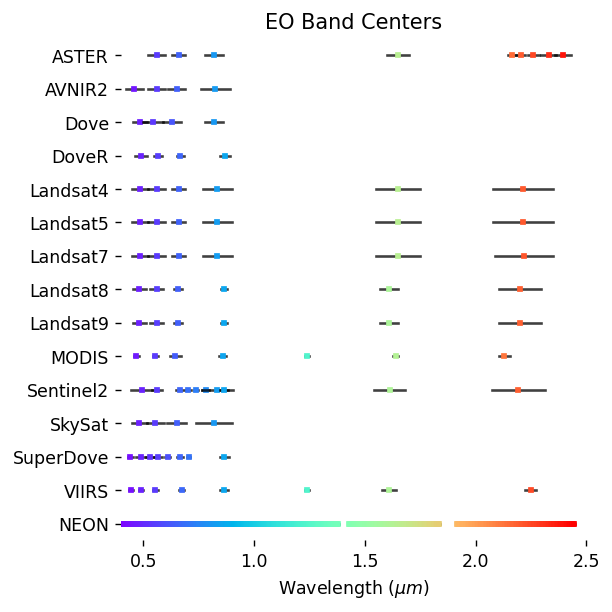

In [2]:
title = 'EO Band Centers'
cmap = plt.cm.rainbow
wavelengths = library.sensor.band_centers

# set the plot range
xlim = [wavelengths.min(), wavelengths.max()]
xticks = [0.5, 1.0, 1.5, 2.0, 2.5]

# get the full sensor list
sensors = earthlib.sensors.list_sensors()
sensors.sort()

# drop missing band width definitions
missing = ['ASD', 'Earthlib']
for m in missing:
    sensors.pop(sensors.index(m))

# put NEON on the bottom
sensors.pop(sensors.index('NEON'))
sensors.append('NEON')

# set up the plot
plt.figure(figsize=figsize, dpi=dpi, facecolor=facecolor)

# plot each one
yticks = np.arange(len(sensors), 0, -1)
for sensor, ytick in zip(sensors, yticks):
    s = earthlib.sensors.get_sensor(sensor)
    centers = s.band_centers
    widths = s.band_widths
    
    # plot each line
    for center, width in zip(centers, widths):
        xmin = center - (width / 2)
        xmax = center + (width / 2)
        
        # get the color based on the center wavelength
        fraction = (center - xlim[0]) / (xlim[1] - xlim[0])
        band_color = cmap(fraction)
        
        # plot the full band width
        plt.plot(
            [xmin, xmax],
            [ytick, ytick],
            color='black',
            linewidth=1.5,
            alpha=0.75,
        )
        
        # plot the band center
        plt.plot(
            center,
            ytick,
            color=band_color,
            marker='s',
            markersize=2,
        )

# labeling
plt.title(title)
plt.xlabel("Wavelength ($\mu m$)")
plt.yticks(yticks, sensors)

# styling
plt.xlim(xlim)
plt.xticks(xticks, xticks)
plt.ylim(yticks.min() - 0.5, yticks.max() + 0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.tight_layout()

# saving
plt.savefig(
    os.path.join(plots, f'supported-sensors.png'),
    dpi=dpi,
    facecolor=facecolor,
)